# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 05: STRUCTURED MODEL USING MEDIUM SUBSET
# ============================================================
# Purpose:
# This notebook repeats the structured modelling process using
# the FMA medium subset to test scalability and performance.
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# ============================================================
# 2. LOAD DATA
# ============================================================

tracks = pd.read_csv(
    "../data/raw/metadata/tracks.csv",
    header=[0, 1],
    index_col=0
)

features = pd.read_csv(
    "../data/raw/metadata/features.csv",
    header=[0, 1, 2],
    index_col=0
)

print("Tracks:", tracks.shape)
print("Features:", features.shape)

Tracks: (106574, 52)
Features: (106574, 518)


In [3]:
# ============================================================
# 3. FILTER TO MEDIUM SUBSET
# ============================================================

subset_name = "medium"

tracks_medium = tracks[tracks[("set", "subset")] == subset_name]
features_medium = features.loc[tracks_medium.index]

print("Medium tracks:", tracks_medium.shape)
print("Medium features:", features_medium.shape)


Medium tracks: (17000, 52)
Medium features: (17000, 518)


In [4]:
# ============================================================
# 4. CHECK GENRE DISTRIBUTION
# ============================================================

genre_counts = tracks_medium[("track", "genre_top")].value_counts()

print("Genre distribution:")
print(genre_counts)


Genre distribution:
(track, genre_top)
Rock                   6103
Electronic             5314
Experimental           1251
Hip-Hop                1201
Classical               619
Folk                    519
Old-Time / Historic     510
Jazz                    384
Instrumental            350
Pop                     186
Country                 178
Soul-RnB                154
Spoken                  118
Blues                    74
Easy Listening           21
International            18
Name: count, dtype: int64


In [5]:
# ============================================================
# 5. PREPARE X, y, AND SPLIT
# ============================================================

labels = tracks_medium[("track", "genre_top")]
splits = tracks_medium[("set", "split")]

valid = labels.notna()

X = features_medium[valid]
y = labels[valid]
split = splits[valid]

X = X.select_dtypes(include=["number"])
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

print("Clean X:", X.shape)
print("Clean y:", y.shape)

Clean X: (17000, 518)
Clean y: (17000,)


In [6]:
# ============================================================
# 6. CREATE TRAIN / VALIDATION / TEST SETS
# ============================================================

X_train = X[split == "training"]
y_train = y[split == "training"]

X_val = X[split == "validation"]
y_val = y[split == "validation"]

X_test = X[split == "test"]
y_test = y[split == "test"]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (13522, 518)
Validation: (1705, 518)
Test: (1773, 518)


In [7]:
# ============================================================
# 7. SCALE FEATURES FOR SVM
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [8]:
# ============================================================
# 8. MODEL 1: RANDOM FOREST
# ============================================================
# Random Forest is useful because it performs well on tabular
# features and provides feature importance.

print("\n===== MEDIUM RANDOM FOREST =====")

rf_medium = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_medium.fit(X_train, y_train)

val_pred_rf = rf_medium.predict(X_val)

print("Random Forest Validation Accuracy:",
      accuracy_score(y_val, val_pred_rf))

print(classification_report(y_val, val_pred_rf))


===== MEDIUM RANDOM FOREST =====
Random Forest Validation Accuracy: 0.6973607038123167
                     precision    recall  f1-score   support

              Blues       0.00      0.00      0.00         8
          Classical       0.75      0.92      0.83        62
            Country       0.00      0.00      0.00        18
     Easy Listening       0.00      0.00      0.00         2
         Electronic       0.62      0.91      0.74       532
       Experimental       0.35      0.06      0.10       125
               Folk       0.61      0.44      0.51        52
            Hip-Hop       0.70      0.13      0.22       120
       Instrumental       0.00      0.00      0.00        31
      International       0.00      0.00      0.00         2
               Jazz       0.00      0.00      0.00        39
Old-Time / Historic       0.93      0.76      0.84        51
                Pop       0.00      0.00      0.00        22
               Rock       0.78      0.92      0.84       

c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [9]:
# ============================================================
# 9. MODEL 2: SVM
# ============================================================
# SVM performed well on the small subset, so it is tested again
# on the larger medium subset.

print("\n===== MEDIUM SVM =====")

svm_medium = SVC(
    C=10,
    kernel="rbf",
    gamma="scale"
)

svm_medium.fit(X_train_scaled, y_train)

val_pred_svm = svm_medium.predict(X_val_scaled)

print("SVM Validation Accuracy:",
      accuracy_score(y_val, val_pred_svm))

print(classification_report(y_val, val_pred_svm))


===== MEDIUM SVM =====
SVM Validation Accuracy: 0.7378299120234604
                     precision    recall  f1-score   support

              Blues       0.00      0.00      0.00         8
          Classical       0.89      0.87      0.88        62
            Country       0.00      0.00      0.00        18
     Easy Listening       0.00      0.00      0.00         2
         Electronic       0.73      0.87      0.79       532
       Experimental       0.38      0.27      0.32       125
               Folk       0.54      0.62      0.58        52
            Hip-Hop       0.66      0.57      0.61       120
       Instrumental       0.00      0.00      0.00        31
      International       1.00      0.50      0.67         2
               Jazz       0.42      0.36      0.39        39
Old-Time / Historic       0.93      0.75      0.83        51
                Pop       0.00      0.00      0.00        22
               Rock       0.83      0.90      0.86       611
           Soul-

c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [10]:
# ============================================================
# 10. FINAL TEST EVALUATION
# ============================================================
# Select the best validation model.
# For now, this code evaluates SVM because it usually performs well.

print("\n===== FINAL TEST EVALUATION: MEDIUM SVM =====")

test_pred_svm = svm_medium.predict(X_test_scaled)

print("SVM Test Accuracy:",
      accuracy_score(y_test, test_pred_svm))

print(classification_report(y_test, test_pred_svm))


===== FINAL TEST EVALUATION: MEDIUM SVM =====
SVM Test Accuracy: 0.7202481669486746
                     precision    recall  f1-score   support

              Blues       0.00      0.00      0.00         8
          Classical       0.78      0.84      0.81        62
            Country       0.00      0.00      0.00        18
     Easy Listening       0.00      0.00      0.00         6
         Electronic       0.71      0.86      0.78       532
       Experimental       0.39      0.39      0.39       125
               Folk       0.49      0.54      0.51        52
            Hip-Hop       0.73      0.59      0.65       120
       Instrumental       0.29      0.03      0.05        74
      International       0.00      0.00      0.00         2
               Jazz       0.74      0.59      0.66        39
Old-Time / Historic       0.96      0.98      0.97        51
                Pop       0.00      0.00      0.00        19
               Rock       0.79      0.88      0.83       611

c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

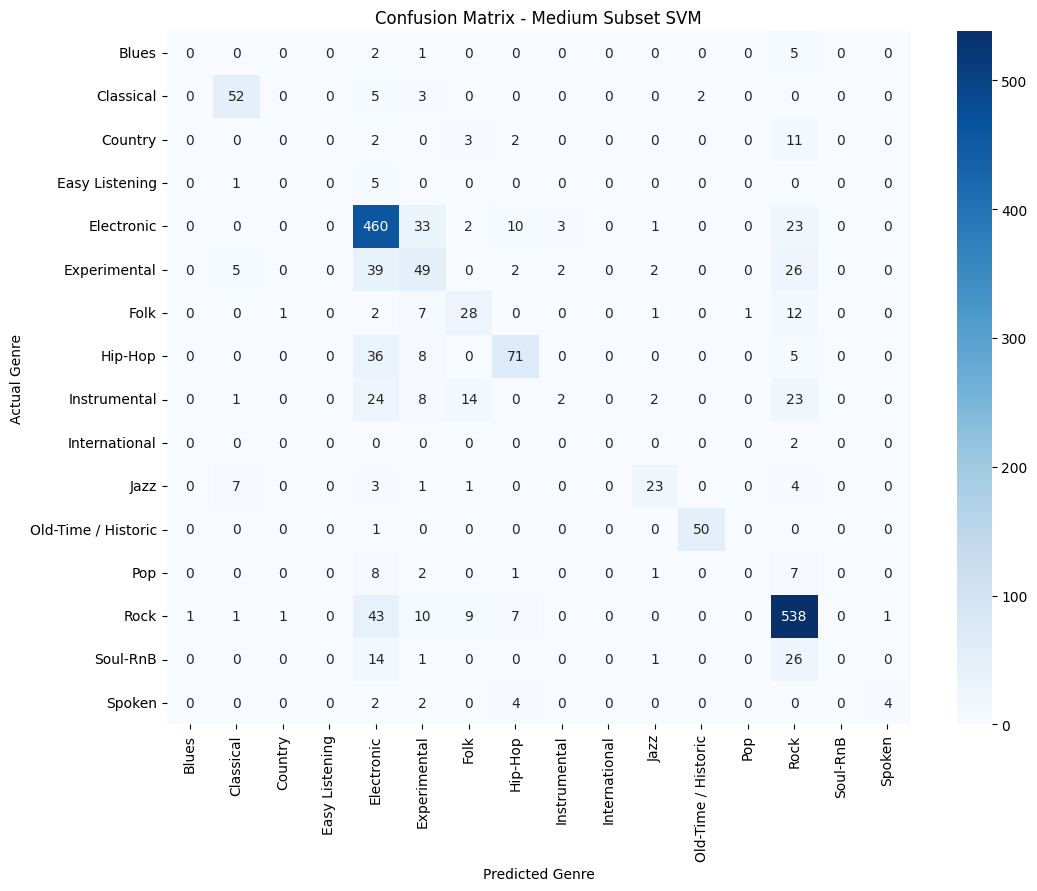

In [11]:
# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, test_pred_svm)

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=svm_medium.classes_,
    yticklabels=svm_medium.classes_
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Confusion Matrix - Medium Subset SVM")
plt.show()


Top 20 Important Features:
feature            statistics  number
mfcc               median      03        0.018284
                   mean        03        0.017068
                   skew        03        0.010538
                   max         04        0.010227
spectral_centroid  std         01        0.009634
mfcc               mean        01        0.009364
                   median      20        0.009099
                   std         14        0.008934
                   median      01        0.008897
                   std         15        0.008664
                   mean        20        0.008553
                   std         13        0.007691
spectral_rolloff   std         01        0.007659
mfcc               mean        04        0.007294
                   std         16        0.007054
                   max         03        0.006875
                   median      04        0.006860
                   std         17        0.006696
                   skew        01  

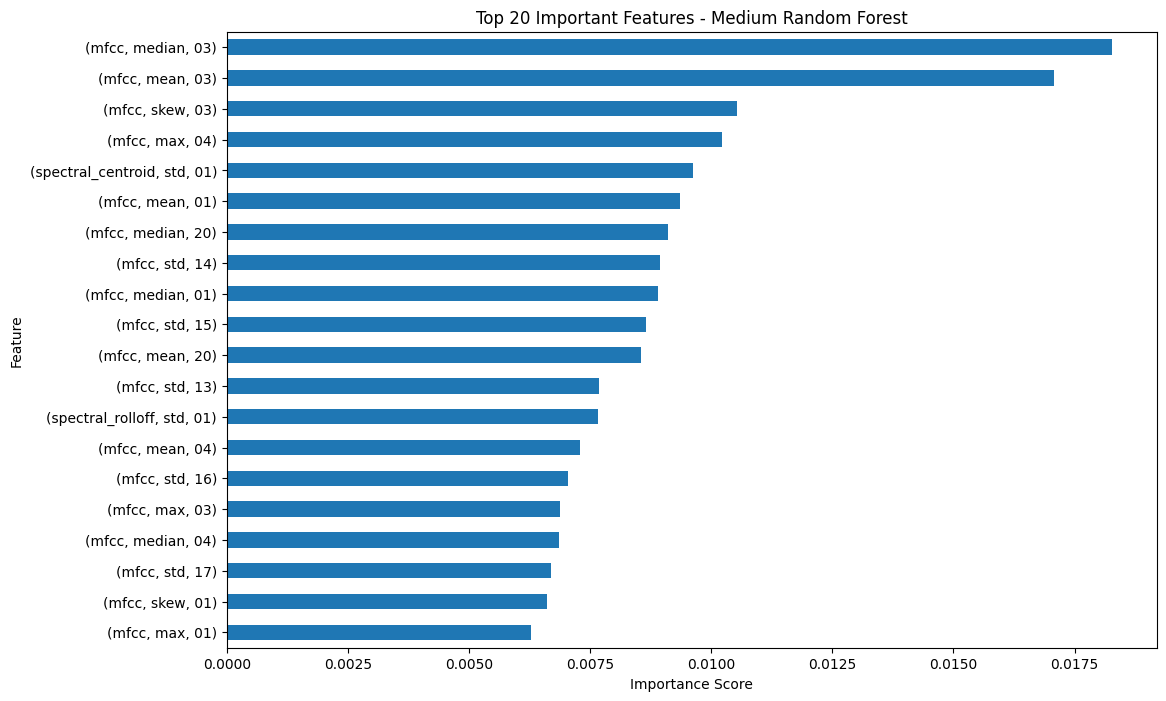

In [12]:
# ============================================================
# 12. FEATURE IMPORTANCE USING RANDOM FOREST
# ============================================================

feature_importance = pd.Series(
    rf_medium.feature_importances_,
    index=X.columns
)

top_features = feature_importance.sort_values(ascending=False).head(20)

print("Top 20 Important Features:")
print(top_features)

plt.figure(figsize=(12, 8))
top_features.sort_values().plot(kind="barh")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 20 Important Features - Medium Random Forest")
plt.show()

In [13]:
# ============================================================
# 13. MODEL COMPARISON SUMMARY
# ============================================================

medium_results = pd.DataFrame({
    "Model": [
        "Medium Random Forest",
        "Medium SVM"
    ],
    "Validation Accuracy": [
        accuracy_score(y_val, val_pred_rf),
        accuracy_score(y_val, val_pred_svm)
    ]
})

print("Medium Model Comparison:")
display(medium_results)

Medium Model Comparison:


,Model,Validation Accuracy
0,Medium Random Forest,0.697361
1,Medium SVM,0.737830


In [14]:
# ============================================================
# 14. IMPROVED SVM WITH CLASS BALANCING
# ============================================================

print("\n===== SVM WITH CLASS BALANCING =====")

svm_balanced = SVC(
    C=10,
    kernel="rbf",
    gamma="scale",
    class_weight="balanced"
)

svm_balanced.fit(X_train_scaled, y_train)

val_pred_balanced = svm_balanced.predict(X_val_scaled)

print("Balanced SVM Validation Accuracy:",
      accuracy_score(y_val, val_pred_balanced))

print(classification_report(y_val, val_pred_balanced))


===== SVM WITH CLASS BALANCING =====
Balanced SVM Validation Accuracy: 0.7442815249266862
                     precision    recall  f1-score   support

              Blues       0.00      0.00      0.00         8
          Classical       0.83      0.89      0.86        62
            Country       0.00      0.00      0.00        18
     Easy Listening       0.00      0.00      0.00         2
         Electronic       0.75      0.87      0.80       532
       Experimental       0.41      0.35      0.38       125
               Folk       0.52      0.65      0.58        52
            Hip-Hop       0.63      0.63      0.63       120
       Instrumental       0.00      0.00      0.00        31
      International       1.00      0.50      0.67         2
               Jazz       0.41      0.36      0.38        39
Old-Time / Historic       0.93      0.75      0.83        51
                Pop       0.00      0.00      0.00        22
               Rock       0.86      0.89      0.87    

c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [15]:
print("\n===== FINAL TEST: BALANCED SVM =====")

test_pred_balanced = svm_balanced.predict(X_test_scaled)

print("Balanced SVM Test Accuracy:",
      accuracy_score(y_test, test_pred_balanced))

print(classification_report(y_test, test_pred_balanced))


===== FINAL TEST: BALANCED SVM =====
Balanced SVM Test Accuracy: 0.7225042301184433
                     precision    recall  f1-score   support

              Blues       0.00      0.00      0.00         8
          Classical       0.73      0.84      0.78        62
            Country       0.33      0.06      0.10        18
     Easy Listening       0.00      0.00      0.00         6
         Electronic       0.74      0.85      0.79       532
       Experimental       0.41      0.46      0.43       125
               Folk       0.47      0.60      0.53        52
            Hip-Hop       0.70      0.66      0.68       120
       Instrumental       0.22      0.03      0.05        74
      International       0.00      0.00      0.00         2
               Jazz       0.64      0.59      0.61        39
Old-Time / Historic       0.96      0.98      0.97        51
                Pop       0.00      0.00      0.00        19
               Rock       0.80      0.86      0.83       611

c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif